# Vizuelizacija podataka sa Matplotlib-om

U Pajtonu, jedan od najboljih paketa za grafičko prikazivanja podataka je **matplotlib**. Ako posetite [Matplotlib galeriju](https://www.matplotlib.org/gallery/index#gallery) možete da vidite šta se sve može napraviti.

## Opšti saveti za Matplotlib

### Uvoz matplotlib-a

Kao što koristimo np skraćenicu za NumPy i pd skraćenicu za Pandas, tako koristimo i neke standardne skraćenice za uvoz iz Matplotliba.

In [1]:
import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np

### Opšti koncepti

Postoje neki opšti koncepti koje bi trebalo razumeti kako bi krenuli sa praktičnim primerima i zadacima. Objekat *figure* kreiran matpolotlib-om ima veliki broj elemenata i ovde ćemo diskutovati o tim elementima.

1. **Figure** je *platno**(ceo prozor) na kojem se stvaraju različiti crteži i dodatni elementi. Objekat figure sadrži jedan ili više axes/plot(subplots) (osnova/crteža) objekata. Sintaksa funkcije figure
```python
plt.figure(num, figsize, dpi, facecolor, edgecolor, frameon, **kwargs)
```
 
2. **Axes**(Osnova, nosač) Oblast slike sa podacima je Axes objekat. Uz pomoć Axes objekta možemo da crtamo u bilo kom delu figure (to omogućava i kreiranje pod grafika). Svaka figura može imati mnogo axes objekata, ali dati axes objekat može postojati samo u jednoj figuri. U dve dimenzije, axes sadrži dva axis objekta, a u slučaju 3D tri axis objekta. Kako bi dodali axes objekat u figuru treba samo pozvati metod `add_axes()`:
```python
plt.axes(levo, dole, širina, visina)
```
 
4. **Axis (Osa)** u Matplotlib figuri se koristi za generisanje ograničenja grafikona i u osnovi je kao brojna linija. Može postojati X osa, Y osa i Z osa za grafikone do 3 dimenzije.

5. **Artist** (Umetnik) je sve što se može videti na figuri. Većina umetnika je vezana za Axes objekte. Oni su poput tekstualnih objekata, Line2D objekti i još mnogo toga.


API `matplotlib.pyplot` je u osnovi kolekcija funkcija komandnog stila čija je namena izrada  interaktivnog grafika. Svaka funkcija u pyplot-u pravi neke izmene na slici, na primer, postoji funkcija da stvori figuru, funkcija koja stvara oblast(i) za iscrtavanje u figuri, za iscrtavanje nekih linija u oblasti za crtanje, kao i za ukrašavanje grafika etiketama.

```{figure} Slike/anatomy_mpl.png
:width: 400px
:align: center

Anatomija slike u matplotlib-u
```

### Osnovni metod: `plot`

Osnovni metod za crtanje je `plot.` Njegova sintaksa je:
```python
matplotlib.pyplot.plot(*args, scalex=True, scaley=True, data=None, **kwargs)
```
ili, u nešto jednostavnijem obliku:
```python
plot([x], y, [fmt], [x2], y2, [fmt2], ..., **kwargs)
```

gde su `x`, `y` koordinate tačaka (ili čvorovi) koje treba spojiti, a `fmt` opcioni parametri za razna podešavanja

```{admonition} Primer 1.
:class: tip 
Linijskim dijagramom prikazati podatke o dnevnoj temperaturi, ako su podaci o temperaturi sačuvani u listi 
    `temperatura = [36.6, 37, 37.7,39,40.1,43,43.4,45,45.6,40.1,44,45,46.8,47,47.8]`.
```

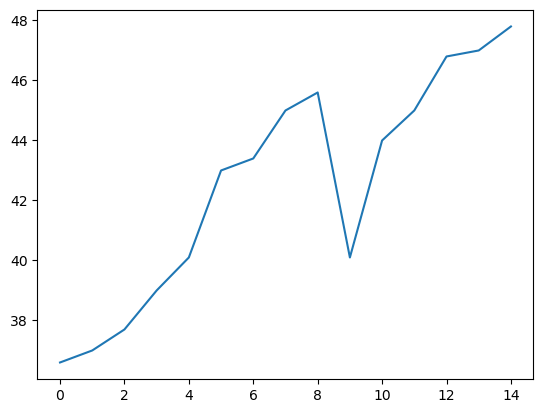

In [2]:
temperatura = [36.6, 37, 37.7,39,40.1,43,43.4,45,45.6,40.1,44,45,46.8,47,47.8]
plt.plot(temperatura)
plt.show()

Podsetimo se: magičnom komandom ? posle imena metoda možemo uvek da potražimo pomoć u vezi sintakse.

In [ ]:
plt.figure?

Sad možemo malo da doteramo dijagram, tako da se vidi o čemu se radi.

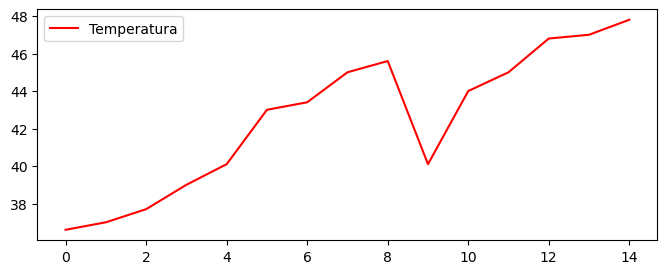

In [4]:
plt.figure('Prvi dijagram', figsize=(8,3), facecolor = 'lightblue', edgecolor='lightgreen', frameon=False)
temperatura = [36.6, 37, 37.7,39,40.1,43,43.4,45,45.6,40.1,44,45,46.8,47,47.8]
plt.plot(temperatura, color='r', label='Temperatura')
plt.legend()
plt.figure
plt.show()

```{admonition} Primer 2.
:class: tip 
Skicirajte grafike funkcija $f(x) = x^2+2$ i $g(x)=\cosh(x)= \dfrac{e^{x}+e^{-x}}2$ za $-1 \le x \le 1$.

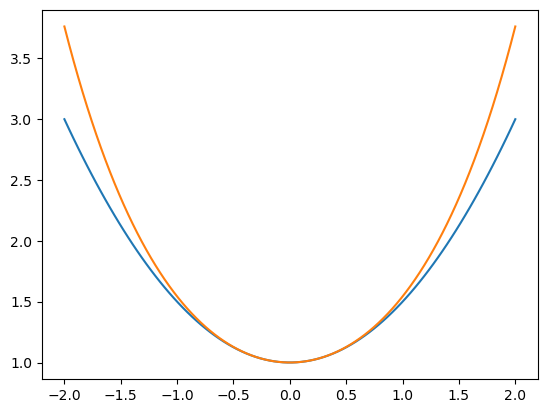

In [5]:
x = np.linspace(-2,2,100)
f=x**2/2+1
g=(np.exp(x)+np.exp(-x))/2   # Lančanica ili cosinus hiperbolikus
plt.plot(x,f)
plt.plot(x,g)
plt.show()

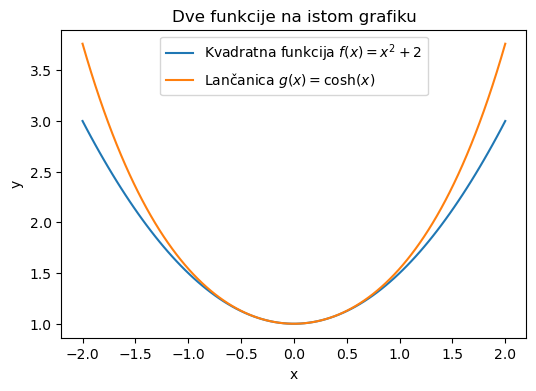

In [6]:
plt.figure('Kvadratna funkcija i lančanica', figsize=(6,4))
x = np.linspace(-2,2,100) # Kreira numpy ndarray, tako što u intervalu [-2,2] umetne 200 jedanko razmaknutih tačaka
f=x**2/2+1
g=(np.exp(x)+np.exp(-x))/2   # Lančanica ili cosinus hiperbolikus
plt.plot(x, f, label=r'Kvadratna funkcija $f(x) = x^2+2$')
plt.plot(x, g, label=r'Lančanica $g(x)=\cosh(x)$')
plt.legend()
plt.title('Dve funkcije na istom grafiku')
plt.xlabel('x')
plt.ylabel('y')
plt.show()

###  Podešavanje podrazumevanih vrednosti

Matplotlib se pokreće sa skupom podrazumevanih postavki. Možemo da kontrolišemo podrazumevane vrednosti skoro svakog svojstva u matplotlib-u kao što je veličina figure, dpi, širina linije, boja linije, stil linije, osnove, svojstva osnove i mreže, svojstva teksta i fonta i tako dalje. Prethodni grafik napravili smo koristeći podrazumevane vrednosti.

Ako želimo da promenimo neku podrazumevanu vrednost moramo inctancirati figuru. U skripti ispod smo instancirali (i komentarisali) neke postavke figure koje utiču na izgled. Podešavanja su eksplicitno podešena, ali sada možete interaktivno da se igrate sa vrednostima i istražite njihov uticaj.

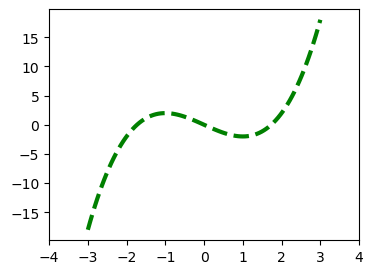

In [7]:
plt.figure(figsize=(4, 3), dpi= 100)  # Kreira figuru veličine 4x3 inča, sa rezolucijom 100 tačaka po inču
x = np.linspace(-3, 3, 100)
y = x**3-3*x
plt.plot(x, y, color = 'green', linewidth = 3, linestyle = '--')  
# linijski grafik isprekidanom crvenom linijom debljine 3 pointa (umesto color može stojati i samo c)
plt.xticks(np.linspace(-4,4,9)) # Markeri na x-osi
plt.show()  #Prikaži grafik

Kasnije ćemo pokazati kako se može promeniti bilo koji deo figure ili dodati neki element, kao što su na primer labela ose, naslov, legenda, tip grafika ... Međutim, postoji i neki predefinisani stilovi koji automatski definišu stil. Evo liste tih stilova.

In [8]:
print(plt.style.available)

['Solarize_Light2', '_classic_test_patch', '_mpl-gallery', '_mpl-gallery-nogrid', 'bmh', 'classic', 'dark_background', 'fast', 'fivethirtyeight', 'ggplot', 'grayscale', 'petroff10', 'seaborn-v0_8', 'seaborn-v0_8-bright', 'seaborn-v0_8-colorblind', 'seaborn-v0_8-dark', 'seaborn-v0_8-dark-palette', 'seaborn-v0_8-darkgrid', 'seaborn-v0_8-deep', 'seaborn-v0_8-muted', 'seaborn-v0_8-notebook', 'seaborn-v0_8-paper', 'seaborn-v0_8-pastel', 'seaborn-v0_8-poster', 'seaborn-v0_8-talk', 'seaborn-v0_8-ticks', 'seaborn-v0_8-white', 'seaborn-v0_8-whitegrid', 'tableau-colorblind10']


Standardni stil možemo promeniti primenom funkcije `plt.style.use`

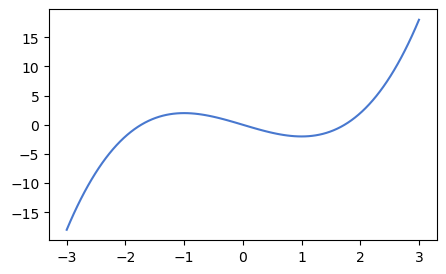

In [9]:
plt.style.use("seaborn-v0_8-muted")
import numpy as np
fig = plt.figure(figsize=(5,3)) 
x = np.linspace(-3,3,100)
plt.plot(x, x**3-3*x)
plt.show()

Za povratak na podrazumevani stil koristimo:

In [10]:
plt.style.use("default")

### Čuvanje Figura u datoteci

Jedna lepa karakteristika Matplotliba je sposobnost čuvanja figura u najrazličitijim formatima. Možete sačuvati figuru pomoću naredbe `savefig().` Na primer, da biste sačuvali prethodnu sliku kao PNG datoteku, možete pokrenuti:

In [11]:
fig.savefig('my_figure.png')

Sada imamo datoteku koja se zove *my_figure.png* u trenutnom radnom direktorijumu.

U metodu `savefig()`, format datoteke se određuje iz ekstenzije datog imena datoteke. Spisak podržanih tipova datoteka za vaš sistem možete pronaći pomoću sledećeg metoda objekta figure `canvas`:

In [34]:
fig.canvas.get_supported_filetypes()

{'eps': 'Encapsulated Postscript',
 'jpg': 'Joint Photographic Experts Group',
 'jpeg': 'Joint Photographic Experts Group',
 'pdf': 'Portable Document Format',
 'pgf': 'PGF code for LaTeX',
 'png': 'Portable Network Graphics',
 'ps': 'Postscript',
 'raw': 'Raw RGBA bitmap',
 'rgba': 'Raw RGBA bitmap',
 'svg': 'Scalable Vector Graphics',
 'svgz': 'Scalable Vector Graphics',
 'tif': 'Tagged Image File Format',
 'tiff': 'Tagged Image File Format',
 'webp': 'WebP Image Format'}

## Dva interfejsa

Potencijalno zbunjujuća karakteristika Matplotliba su njegovi dvostruki interfejsi: prvi, sistem zasnovan na MATLAB stilu i drugi, moćniji, objektno orijentisani interfejs. Ovde ćemo brzo istaknuti razlike između njih.

#### MATLAB - stil interfejs

Matplotlib je prvobitno napisan kao Python alternativa za korisnike MATLAB-a i veći deo njegove sintakse odražava tu činjenicu. Alati u stilu MATLAB nalaze se u `pyplot`(`plt`) interfejsu. Na primer, sledeći kod će verovatno izgledati prilično poznato korisnicima MATLAB-a:

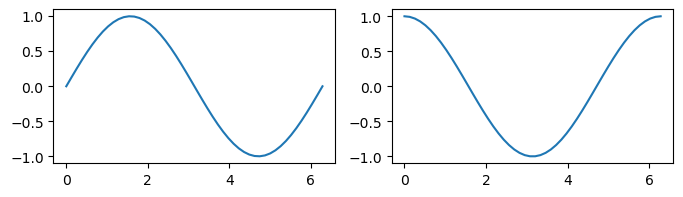

In [12]:
x = np.linspace(0,2*np.pi,50)
plt.figure(figsize=(8,2)) # kreira figuru

# kreira prvi od dva panela i postavlja trenutnu osu
plt.subplot(1, 2, 1) # (redovi, kolone, broj panela)
plt.plot(x, np.sin(x))

# kreira drugi od dva panela postavlja trenutnu osu
plt.subplot(1, 2, 2)
plt.plot(x, np.cos(x))
plt.show()

Važno je napomenuti da ovaj interfejs sadrži *status*: on prati ,,trenutnu'' figuru i osnovu, gde se primenjuju sve `plt` komande. Možete dobiti referencu na ove elemente pomoću `plt.gcf()` (dobijate trenutnu cifru) i `plt.gca()` (dobijte trenutne osnove) rutine.

Iako je ovaj interfejs sa statusom brz i prikladan za jednostavne crteže, lako je pokrenuti probleme. Na primer, kada se kreira drugi panel, kako se možemo vratiti i dodati nešto prvom? To je moguće u interfejsu u stilu MATLAB, ali pomalo nezgrapno. Srećom, postoji bolji način.

#### Objektno orijentisan interfejs

Objektno orijentisani interfejs je dostupan za složenije situacije, kada želimo veću kontrolu nad svojom figurom. Umesto da zavisi od pojma ,,aktivne'' figure ili ose, u objektno orijentisanom interfejsu funkcije crtanja su metode eksplicitnih objekata `Figure`i `Axes.` Da biste ponovo kreirali prethodni grafik koristeći ovaj stil crtanja, uradimo sledeće:

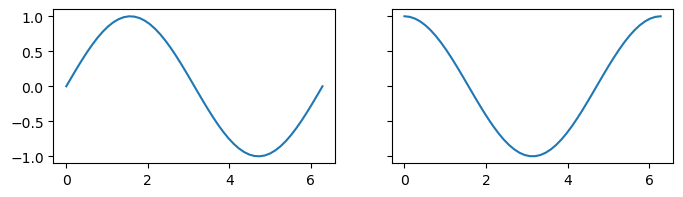

In [13]:
# prvo kreiramo grid grafikona
# ax će biti neki array od dva Axes objekta
fig, ax = plt.subplots(1, 2, figsize=(8,2), sharey = True)
# Pozivanje plot() metoda na odgovarajućim objektima
ax[0].plot(x, np.sin(x))
ax[1].plot(x, np.cos(x))
plt.show()

Za jednostavnije grafike, izbor stila je uglavnom stvar preferencija, ali objektno orijentisani pristup može postati potreba kako grafici postaju sve više komplikovaniji. Kroz ovo poglavlje ćemo se prebacivati između MATLAB stila i objektno orijentisanog interfejsa, u zavisnosti od toga šta je najpogodnije. U većini slučajeva, razlika je mala kao i prebacivanje `plt.plot()` na `ax.plot ()`, ali ima nekoliko dogovora koje ćemo istaknuti kad se pojave u sledećim odeljcima.

## Jednostavni grafikoni sa linijama

Sve Matplotlib grafikone započinjemo sa stvaranjem figure i osnove (Axes). U njihovim najjednostavnijim obliku, figura i osnova mogu se kreirati na sledeći način:

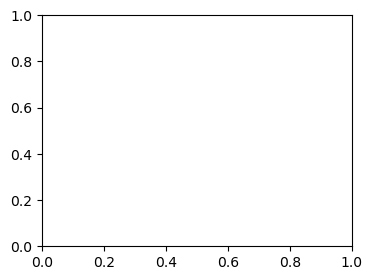

In [14]:
fig = plt.figure(figsize=(4,3))  # prazan prozor bez Nosača (Axes)
ax = plt.axes()

ili, alternativno u jednom potezu

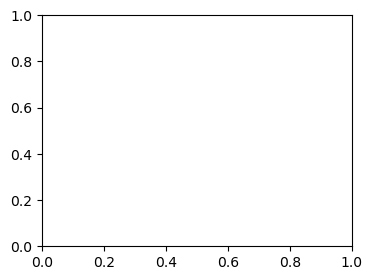

In [15]:
fig, ax = plt.subplots(figsize=(4,3))

U Matplotlibu, *figura* (instanca klase `plt.Figure`) može se smatrati za pojedinačni kontejner koji sadrži sve objekte koji predstavljaju osnove, grafiku, tekst i etikete. *Osnove (axes)* (instanca klase  `plt.Axes`) je ono što vidimo gore iznad na slici: ograničenje okvira sa tikovima i labelama, koja će na kraju sadržati grafikon. Ime promenljive `fig` se odnosi na instancu figure, a `ax` se odnosi na instancu osnove ili grupu instanci osnova.

Jednom kada smo kreirali osnovu, možemo koristiti funkciju `ax.plot` za crtanje nekih podataka. Počnimo sa jednostavnom sinusoidom:

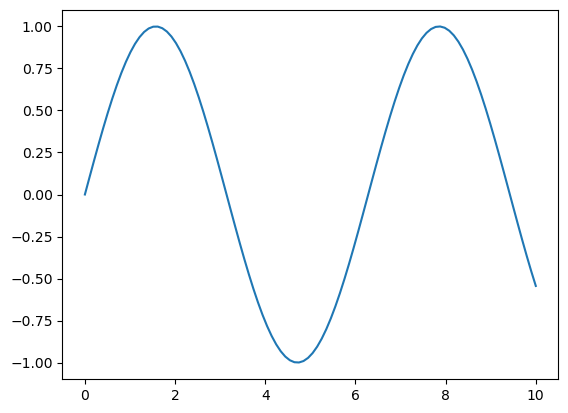

In [16]:
fig, ax = plt.subplots()
x = np.linspace(0, 10, 100)
ax.plot(x, np.sin(x))
plt.show()

Alternativno, možemo koristiti pylab interfejs i dozvoliti da se kreiraju slika i ose u pozadini:

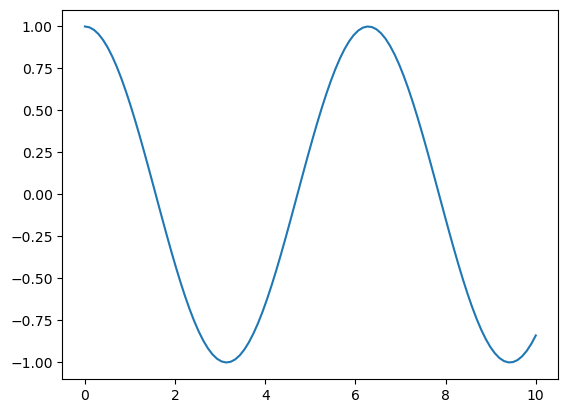

In [17]:
plt.plot(x, np.cos(x))
plt.show()

Tipično, kreiramo novu figuru preko jedne od sledećih funkcija

<Figure size 640x480 with 0 Axes>

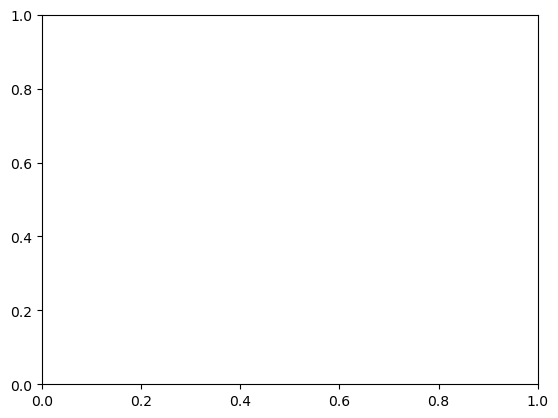

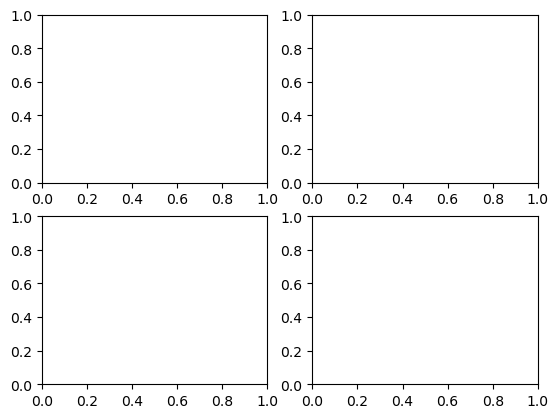

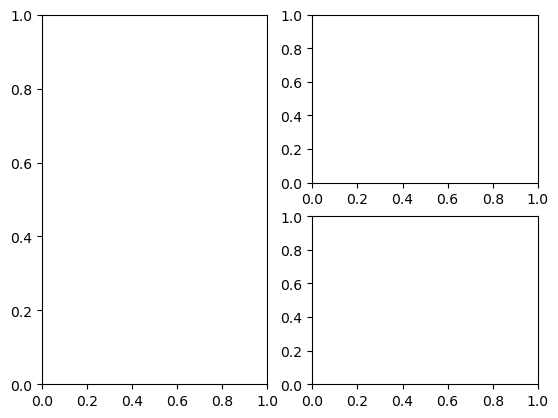

In [18]:
fig = plt.figure()             # Prazna figura bez nosača(Axes)
fig, ax = plt.subplots()       # Figura sa jednim nosačem
fig, axs = plt.subplots(2, 2)  # figura sa rešetkom 2x2  nosača
# Figura sa jednim nosačem levo i dva desno:
fig, axs = plt.subplot_mosaic([['left', 'right_top'],
                               ['left', 'right_bottom']])

### Podešavanje grafika: Boje linija i stilovi

Prvo podešavanje koje biste možda želeli da napravite na grafikonu je upravljanje bojama linija i stilova. Funkcija `plt.plot()` uzima dodatne argumente koji se mogu koristiti za specificiranje. Da biste prilagodili boju, možete koristiti ključnu reč `color` (ili samo `c`) koja prihvata string argument i koji predstavlja praktično bilo koju zamislivu boju. Boja se može navesti na raznovrsne načine:

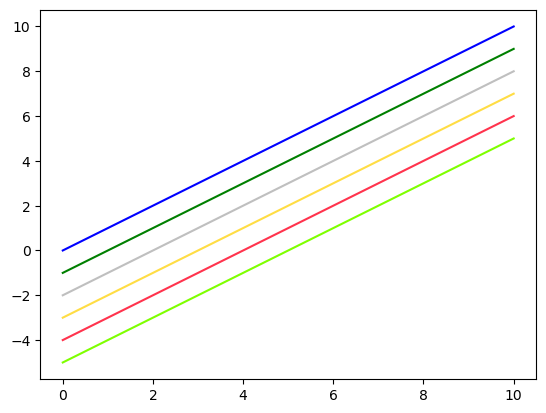

In [20]:
plt.plot(x, x + 0, color='blue') # specifikacija boje po imenu
plt.plot(x, x - 1, c='g') # kratki kod boje (rgbcmyk)
plt.plot(x, x - 2, c='0.75') # Grayscale od 0 do 1
plt.plot(x, x - 3, c='#FFDD44') # Hex code (RRGGBB od 00 do FF)
plt.plot(x, x - 4, c=(1.0,0.2,0.3)) # RGB torka, sa vrednostima od 0  do 1
plt.plot(x, x - 5, c='chartreuse'); # podržana su i sva HTML imena boja

Ako nije navedena boja, Matplotlib će automatski proći kroz podrazumevani skup boja za više linija. Slično tome, stil linije možete prilagoditi pomoću ključne reči `linestyle` (ili samo `ls`):

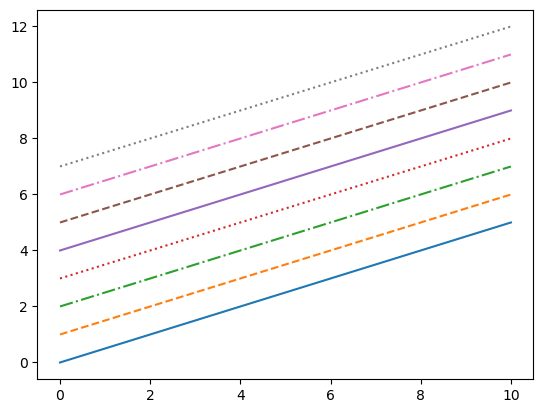

In [21]:
plt.plot(x, x/2 + 0, linestyle='solid')
plt.plot(x, x/2 + 1, ls='dashed')
plt.plot(x, x/2 + 2, ls='dashdot')
plt.plot(x, x/2 + 3, ls='dotted');

# Možemo da koristimo i skraćene kodove:
plt.plot(x, x/2 + 4, ls='-') # solid
plt.plot(x, x/2 + 5, ls='--') # dashed
plt.plot(x, x/2 + 6, ls='-.') # dashdot
plt.plot(x, x/2 + 7, ls=':'); # dotted

Ako želite da budete izuzetno kratki, `linestyle` i `color` kodovi mogu se kombinovati u jedan neključni argument za funkciju `plt.plot()`:

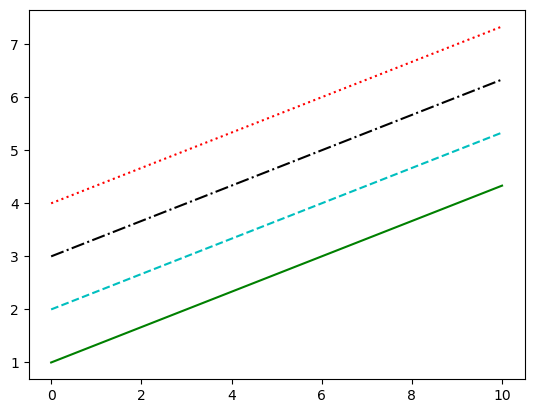

In [24]:
plt.plot(x, x/3 + 1, '-g') # solid green
plt.plot(x, x/3 + 2, '--c') # dashed cyan
plt.plot(x, x/3 + 3, '-.k') # dashdot black
plt.plot(x, x/3 + 4, ':r'); # dotted red

Ovi jednoznakovni kodovi boja odražavaju standardne skraćenice u RGB-u (Crvena/Zelena/Plava) i CMYK (Cijan/Magenta/Žuta/crna) sistem boja, obično se koristi za digitalnu grafiku u boji.

Kako bi promenili marker ili liniju, dodajemo treći ulazni argument u plot, string koji specifikuje boju i stil linije koje će se koristiti na grafiku. Na primer, `plot(x,y,'ro')` će skicirati tačke koristeći crvenu boju (`r`), kružićima (`o`). Moguće specifikacije prikazane su tabeli koja sledi.

```{table} Specifikacije atributa tačaka
:label: point_spec
:align: center
:header-rows: 1

|Simbol   |Opis   |Simbol| Opis      |
|:--:     |:----- | :----|:----------|
|b        |plava  | T    | T         |
|g        |zelena | s    | kvadrat   |
|r        |crvena | d    | deltoid   |
|c        |cyan   | v    | trougao (na dole) |
|m        |magenta| ^    | trougao (na gore  |
|y        |žuta   | <    | trougao (na levo) |
|k        |crna   | >    | trougao (na desno)|
|w        |bela   | p    | pentagram |
|.        |tačka  | h    | heksagram |
|o        |krug   | -    | puna linija |
|x        | x     | :    | dvotačka |
|+        |plus   | -.   | isprekidano + tačke |
|*        |zvezda | --   | isprekidano |

```

### Podešavanje grafika: limitiranje osa

Matplotlib pristojno radi na odabiru zadatih ograničenja osa za vaš grafikon, ali ponekad lepo je imati finiju kontrolu. Najosnovniji način podešavanja ograničenja osa je upotreba metoda `plt.xlim()` i `plt.ylim()`:

(-1.5, 1.5)

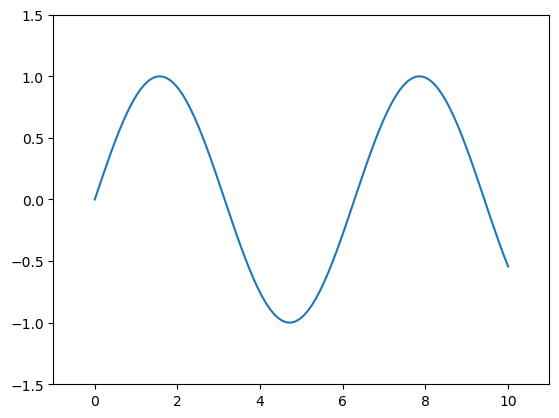

In [25]:
plt.plot(x, np.sin(x))
plt.xlim(-1, 11)
plt.ylim(-1.5, 1.5)

Ako iz nekog razloga želite da se bilo koja osa prikazuje unazad, možete jednostavno obrnuti redosled argumenata:

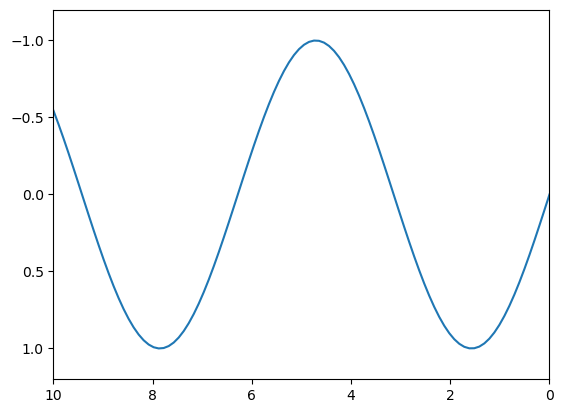

In [26]:
plt.plot(x, np.sin(x))
plt.xlim(10, 0)
plt.ylim(1.2, -1.2);

Korisna srodna metoda je `plt.axis()` (ovde imajte na umu potencijalnu zabunu između *axes* sa *e*, a *axis* sa *i*). Metoda `plt.axis()` vam omogućava da postavite `x` i `y` ograničenja jednim pozivom, prosleđivanjem liste koja navodi `[xmin, xmax, ymin, ymax]`:

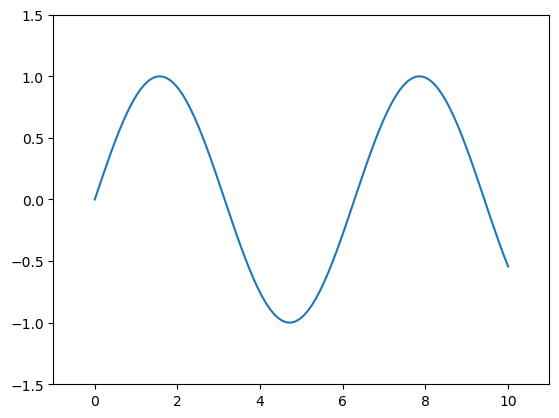

In [27]:
plt.plot(x, np.sin(x))
plt.axis([-1, 11, -1.5, 1.5])
plt.show()

Metoda `plt.axis()` ide i dalje od ovoga, omogućavajući vam da stvari radite automatski stežući granice oko trenutnog grafikona:

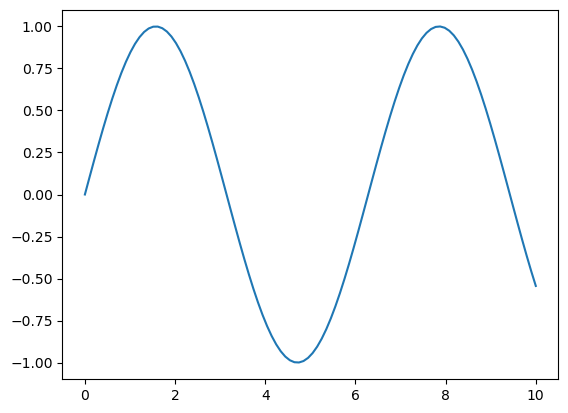

In [28]:
plt.plot(x, np.sin(x))
plt.axis('tight')
plt.show()

Omogućava čak i specifikacije višeg nivoa, kao što je osiguravanje jednakog odnosa širine i visine tj., da je na vašem ekranu jedna jedinica u `x` jednaka jedinici u `y`:

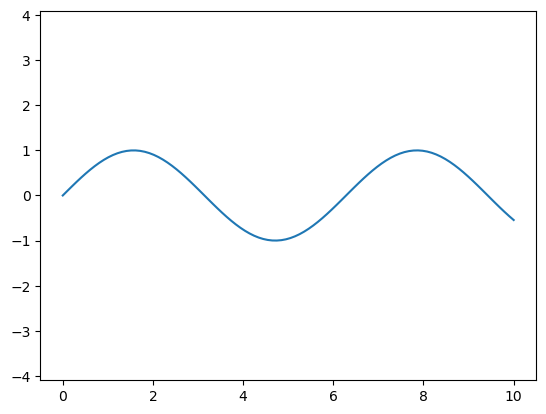

In [29]:
plt.plot(x, np.sin(x))
plt.axis('equal')
plt.show()

Za više informacija o ograničenjima osi i ostalim mogućnostima `plt.axis()` metoda, pogledajte docstring `plt.axis().`

### Labeliranje grafikona

Kao poslednji deo ovog odeljka, ukratko ćemo se osvrnuti na označavanje grafikona kao što su: naslovi, labele osa i jednostavne legende. Naslovi i oznake osa su najjednostavnije takve oznake i postoje metode koje se mogu koristiti da biste ih brzo postavili:

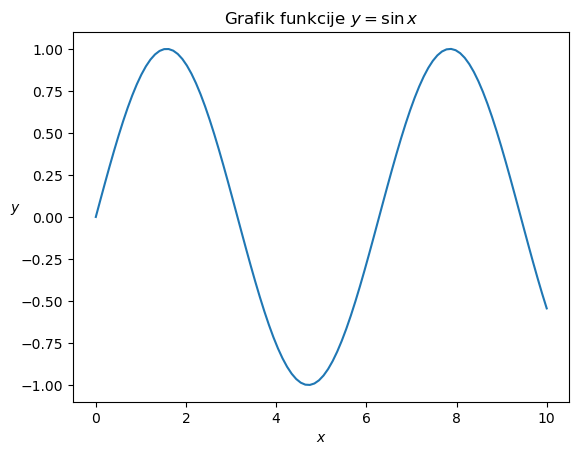

In [30]:
plt.plot(x, np.sin(x))
plt.title(r'Grafik funkcije $y=\sin x$')
plt.xlabel(r'$x$')
plt.ylabel(r'$y$', rotation= 0)
plt.show()

Možete da prilagodite položaj, veličinu i stil ovih nalepnica koristeći opcione argumente funkcija. Za više informacija pogledajte Matplotlib dokumentaciju i docstrings svake od ovih funkcija.

Kada se u okviru jednog axes objekta prikazuje više linija, može biti korisno napraviti legendu grafika koja označava svaki tip linije. Opet, Matplotlib ima ugrađeni način da brzo stvori takvu legendu. To se vrši metodom (pogađate) `plt.legend().`  Iako postoji nekoliko valjanih načina da se ovo koristi, najlakše je odrediti oznaku svakog reda pomoću ključne reči label funkcije plot:

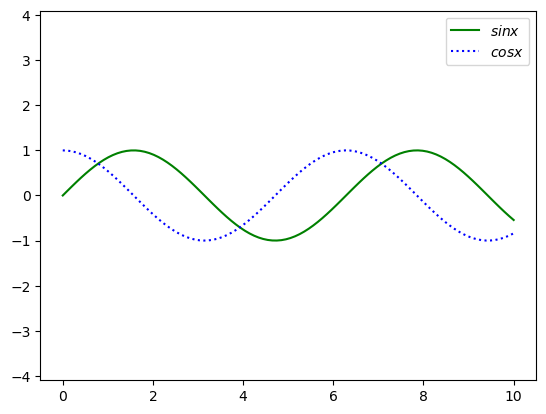

In [31]:
plt.plot(x, np.sin(x), '-g', label=r'$sin x$')
plt.plot(x, np.cos(x), ':b', label=r'$cos x$')
plt.axis('equal')
plt.legend()
plt.show()

Kao što vidite, funkcija `plt.legend()` prati stil linije i boju, i podudara ih sa tačnom oznakom. Više informacija o specificiranju i formatiranju Legende grafikona mogu se naći u docstringu `plt.legend().`

### Matlab stil i Objektno orijentisani stil

Dok se većina `plt` funkcija direktno prevodi u `ax` metode (kao što je `plt.plot() → ax.plot()`, `plt.legend()` → ax.legend()` itd.), to nije slučaj za sve naredbe. Konkretno, funkcije za postavljanje 
ograničenja, oznaka i naslova su malo izmenjene. Za prelazak između funkcija u stilu MATLAB i objektno orijentisanih metoda, izvršite sledeće promene:

```python
• plt.xlabel() → ax.set_xlabel()
• plt.ylabel() → ax.set_ylabel()
• plt.xlim() → ax.set_xlim()
• plt.ylim() → ax.set_ylim()
• plt.title() → ax.set_title()
```

## Jednostavni dijagram rasturanja

Drugi često korišćeni tip grafika je jednostavan dijagram rasturanja, bliski rođak linijskog dijagrama. Umesto da se tačke spajaju segmentima linija, ovde su tačke predstavljene pojedinačno tačkom, krugom ili drugim oblikom. Počećemo sa podešavanjem beležnice za crtanje i uvozom funkcija koje ćemo koristiti:

In [32]:
plt.style.use('fivethirtyeight')

### Dijagram rasturanja sa plt.plot

U prethodnom odeljku smo pogledali `plt.plot` / `ax.plot` da bismo proizveli linijske dijagrame. Ista funkcija može proizvesti i dijagrame rasturanja:

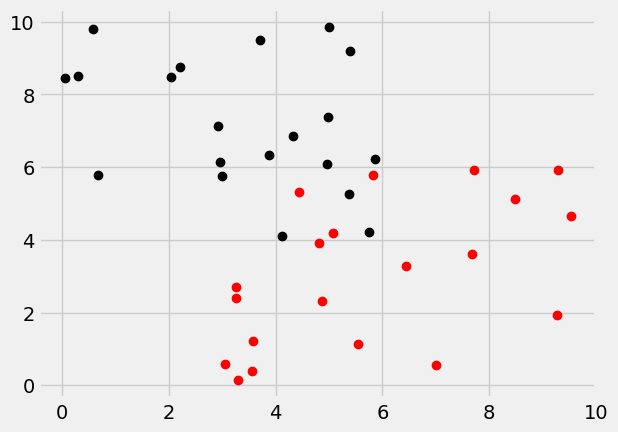

In [91]:
n = 20
np.random.seed(2022)
x = np.random.uniform(0, 6, n)
y = np.random.uniform(4, 10, n)
z = np.random.uniform(3, 10, n)
t = np.random.uniform(0, 6 , n)
plt.plot(x, y, 'o', color='black')
plt.plot(z, t, 'o', color='r')
plt.show()

Treći argument u pozivu funkcije je znak koji predstavlja vrstu simbola koristi se za crtanje. Kao što možete odrediti opcije poput '-' i '-' za kontrolu stila linije, stil markera ima svoj skup kodova sa kratkim stringovima. Cela lista dostupnih simbola mogu se videti u dokumentaciji `plt.plot` ili u Matplotlib-ovoj dokumentacija na mreži. Većina mogućnosti je prilično intuitivna, a mi ćemo pokazati neke od najčešćih:

### Dijagrami rasturanja sa `plt.scatter`

Druga, snažnija metoda za stvaranje dijagrama rasturanja je funkcija `plt.scatter`, koja se može koristiti vrlo slično funkciji `plt.plot`:

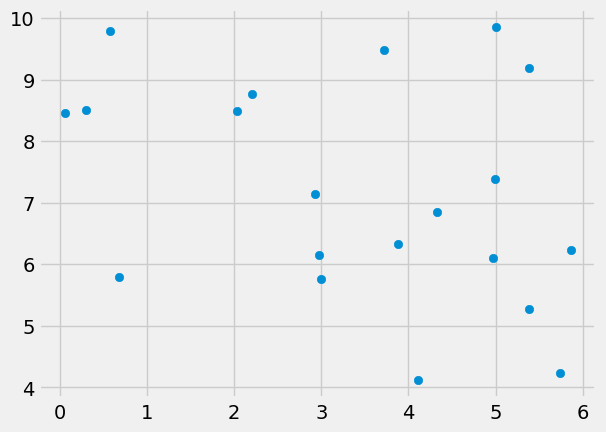

In [95]:
plt.scatter(x, y, marker='o')

Primarna razlika `plt.scatter` u odnosu na `plt.plot` je u tome što se može koristiti za stvaranje dijagrama rasturanja gde se svojstva svake pojedinačne tačke (veličina, boja lica, boja ivica, itd.) mogu pojedinačno kontrolisati ili mapirati. 

Pokažimo ovo stvaranjem slučajnog dijagrama rasturanja sa tačkama u mnogo boja i veličina. Da bismo bolje videli preklapajuće rezultate, koristićemo i ključnu reč `alfa`  za podešavanje nivoa transparentnosti:

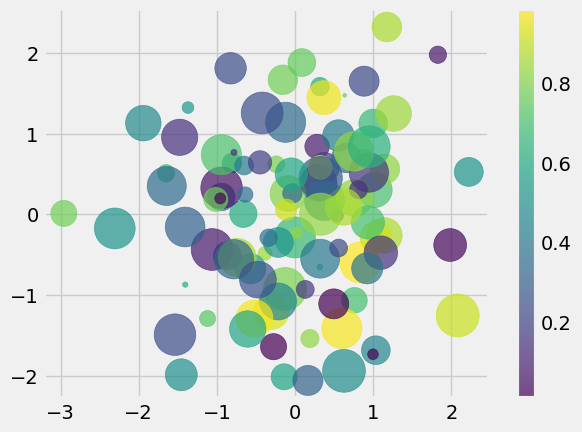

In [97]:
np.random.seed(2022)
x = np.random.randn(100)
y = np.random.randn(100)
colors = np.random.rand(100)
sizes = 1000 * np.random.rand(100)
plt.scatter(x, y, c=colors, s=sizes, alpha=0.7, cmap='viridis')
plt.colorbar(); # prikaži skalu boja

Primetite da se argument boje automatski preslikava na skalu boja (prikazano ovde naredbom `colorbar()` ), a argument veličine dat je u pikselima. Na ovaj način, boja i veličina tačaka mogu se koristiti za prenos informacija u vizualizaciji, odnosno kako bi ilustrovali višedimenzionalne podatke.

## Histogrami, korpe i gustina

Jednostavan histogram može biti odličan prvi korak u razumevanju skupa podataka. 

In [101]:
plt.style.use('classic')

np.random.seed(2022)
data = np.random.randn(1000).round(4)

(array([  7.,  38., 108., 206., 234., 215., 128.,  51.,  12.,   1.]),
 array([-2.9574 , -2.31475, -1.6721 , -1.02945, -0.3868 ,  0.25585,
         0.8985 ,  1.54115,  2.1838 ,  2.82645,  3.4691 ]),
 <BarContainer object of 10 artists>)

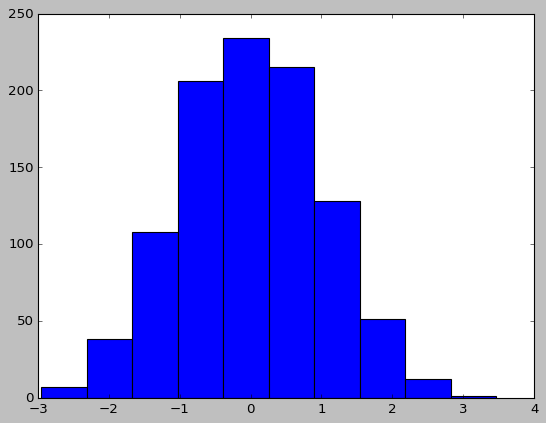

In [102]:
plt.hist(data)

Funkcija `hist()` ima mnogo opcija za podešavanje i izračunavanja i prikaza; evo primera prilagođenijeg histograma:

(array([ 4.,  1.,  2.,  4., 18., 16., 22., 40., 46., 44., 71., 91., 74.,
        81., 79., 70., 85., 60., 53., 52., 23., 23., 14., 14.,  7.,  3.,
         2.,  0.,  0.,  1.]),
 array([-2.9574    , -2.74318333, -2.52896667, -2.31475   , -2.10053333,
        -1.88631667, -1.6721    , -1.45788333, -1.24366667, -1.02945   ,
        -0.81523333, -0.60101667, -0.3868    , -0.17258333,  0.04163333,
         0.25585   ,  0.47006667,  0.68428333,  0.8985    ,  1.11271667,
         1.32693333,  1.54115   ,  1.75536667,  1.96958333,  2.1838    ,
         2.39801667,  2.61223333,  2.82645   ,  3.04066667,  3.25488333,
         3.4691    ]),
 [<matplotlib.patches.Polygon at 0x13f04ab9ee0>])

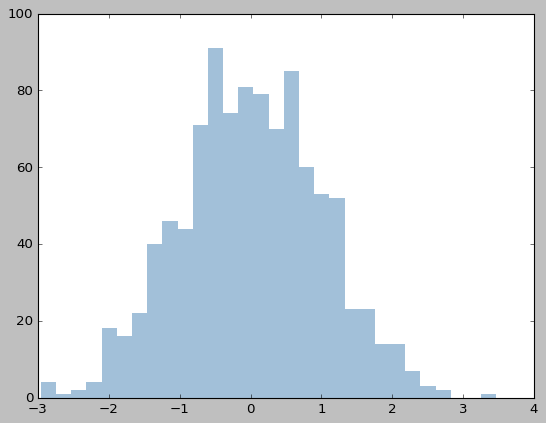

In [104]:
plt.hist(data, bins=30, alpha=0.5, histtype='stepfilled', color='steelblue', edgecolor='None')

Dokumentacija `plt.hist` sadrži više informacija o drugim dostupnim opcijama prilagođavanja. Smatram da je ova kombinacija `histtype = 'stepfilled'` zajedno sa izvesnom transparentnošću `alfa` veoma korisna pri upoređivanju histograma nekoliko distribucija:

(array([ 2.,  2.,  2.,  5., 11.,  4., 11., 16., 23., 25., 23., 43., 50.,
        47., 60., 52., 58., 72., 69., 58., 54., 50., 42., 44., 35., 29.,
        27., 19., 19., 17.,  8.,  7.,  5.,  4.,  1.,  1.,  0.,  2.,  1.,
         2.]),
 array([-2.61861565, -2.30666399, -1.99471233, -1.68276067, -1.37080902,
        -1.05885736, -0.7469057 , -0.43495404, -0.12300238,  0.18894927,
         0.50090093,  0.81285259,  1.12480425,  1.4367559 ,  1.74870756,
         2.06065922,  2.37261088,  2.68456253,  2.99651419,  3.30846585,
         3.62041751,  3.93236917,  4.24432082,  4.55627248,  4.86822414,
         5.1801758 ,  5.49212745,  5.80407911,  6.11603077,  6.42798243,
         6.73993409,  7.05188574,  7.3638374 ,  7.67578906,  7.98774072,
         8.29969237,  8.61164403,  8.92359569,  9.23554735,  9.547499  ,
         9.85945066]),
 [<matplotlib.patches.Polygon at 0x13f04ae6810>])

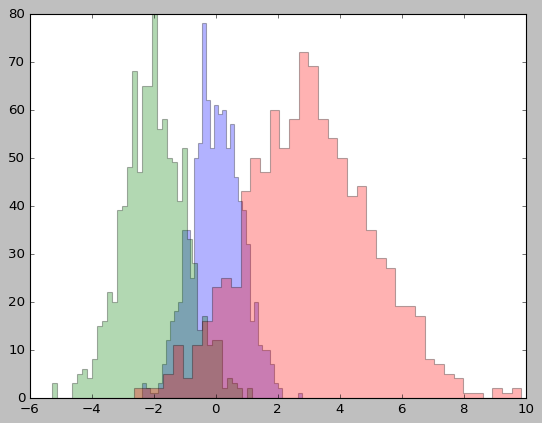

In [106]:
np.random.seed(2022)
x1 = np.random.normal(0, 0.8, 1000)
x2 = np.random.normal(-2, 1, 1000)
x3 = np.random.normal(3, 2, 1000)

kwargs = dict(histtype='stepfilled', alpha=0.3, bins=40)

plt.hist(x1, **kwargs)
plt.hist(x2, **kwargs)
plt.hist(x3, **kwargs)

## Prilagođavanje legendi figure

Legende grafika daju značenje vizuelizaciji, dodeljujući oznake različitim elementima.  Ranije smo videli kako stvoriti jednostavnu legendu; ovde ćemo pogledati prilagođavanje mesta i estetiku legende u Matplotlibu.

Najjednostavnija legenda se može stvoriti pomoću komande `plt.legend()` koja automatski kreira legendu za bilo koji označeni element grafika:

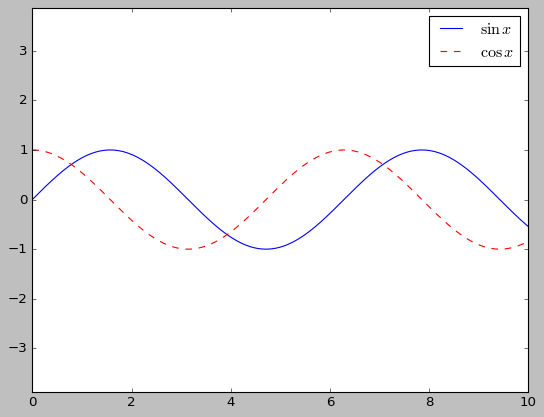

In [109]:
x = np.linspace(0, 10, 1000)
fig, ax = plt.subplots()
ax.plot(x, np.sin(x), '-b', label=r'$\sin x$')
ax.plot(x, np.cos(x), '--r', label=r'$\cos x$')
ax.axis('equal')
ax.legend()
plt.show()

Postoji mnogo načina na koje bismo želeli da prilagodimo takvu legendu. Na primer, možemo odrediti lokaciju i isključiti okvir:

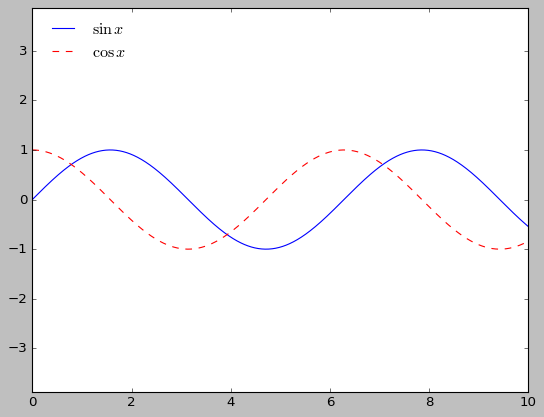

In [111]:
ax.legend(loc='upper left', frameon=False)
fig # primetite da fig sadrži sve prethodne objekte kao super klasa

Komandom `ncol` možemo da odredimo broj kolona u legendi:

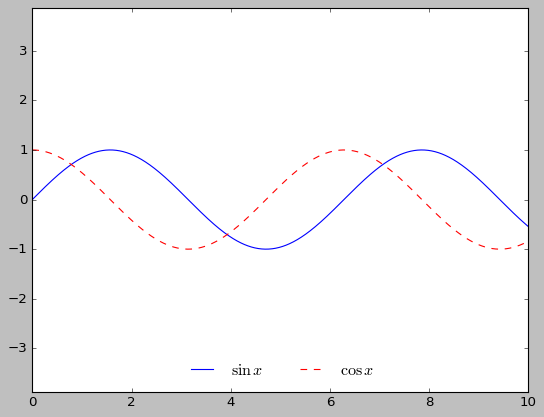

In [113]:
ax.legend(frameon=False, loc='lower center', ncol=2)
fig

Možemo koristiti zaobljeni okvir (`fancybox`) ili dodati senku, promeniti prozirnost (alfa vrednost) okvira ili promenite pozadinu (padding) oko teksta:

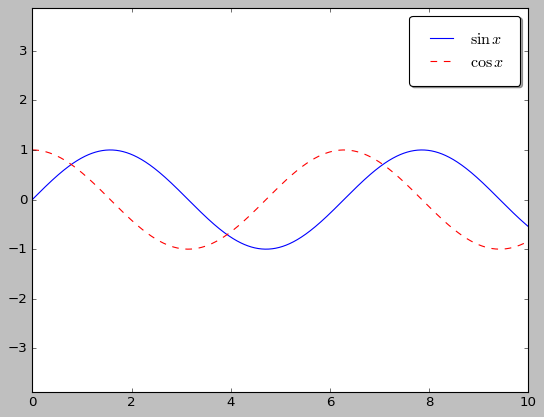

In [115]:
ax.legend(fancybox=True, framealpha=1, shadow=True, borderpad=1)
fig

Za više informacija o dostupnim opcijama legende pogledajte docstring `plt.legend`. 

## Višestruki podgrafici

Ponekad je korisno upoređivati različite poglede na podatke uporedo. U tom cilju, Matplotlib ima koncept *podgrafika*: grupa manjih grafika koje mogu postojati zajedno unutar jedne figure. Ovi podgrafici 
mogu biti umetci, rešetke grafika ili neki drugi složeni izlazi. U ovom odeljku ćemo istražiti četiri rutine za kreiranje potgrafika u Matplotlibu. Započećemo sa podešavanjem beležnice za crtanje i uvoz
funkcija koje ćemo koristiti:

In [119]:
plt.style.use('tableau-colorblind10')

### `plt.subplot`: Jednostrana rešetka podgrafika

Poravnate kolone ili redovi potplota (podgrafika) su dovoljno česta potreba. Matplotlib ima  nekoliko pogodnih rutina koje ih čine jednostavnim za stvaranje. Najniži nivo je `plt.subplot()`, koji kreira jedan podplot unutar mreže. Kao što vidite, ova naredba uzima tri celobrojna argumenta - broj redova, broj kolona, i indeks parcele koja će se kreirati u ovoj šemi, a koja se kreće od gore levo dole desno:

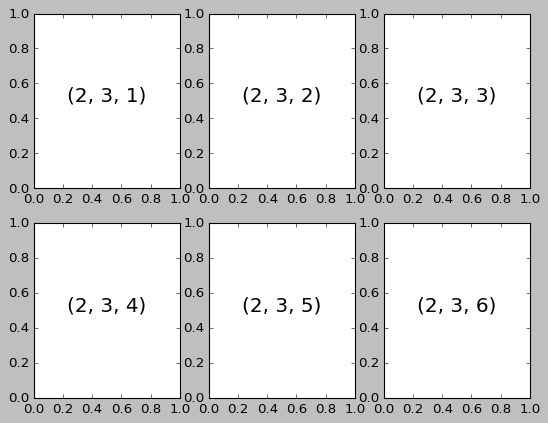

In [122]:
for i in range(1, 7):
    plt.subplot(2, 3, i)
    plt.text(0.5, 0.5, str((2, 3, i)), fontsize=18, ha='center')

Komanda `plt.subplots_adjust` može se koristiti za podešavanje razmaka između ove parcele. Sledeći kod (čiji je rezultat prikazan na sledećoj slici) koristi ekvivalentna objektno orijentisana naredba, `fig.add_subplot()`:

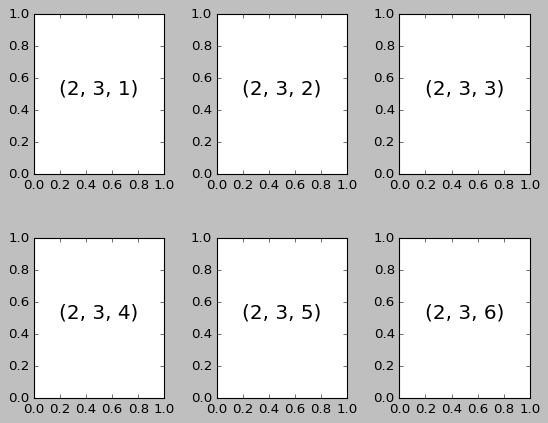

In [124]:
fig = plt.figure()
fig.subplots_adjust(hspace=0.4, wspace=0.4)
for i in range(1, 7):
    ax = fig.add_subplot(2, 3, i)
    ax.text(0.5, 0.5, str((2, 3, i)), fontsize=18, ha='center')

Koristili smo `hspace` i `vspace` argumente `plt.subplots_adjust`, koji preciziraju razmak duž visine i širine slike, u jedinicama veličine podgrafika (u u ovom slučaju prostor je 40% širine i visine 
podgrafika).

### plt.subplots: cela rešetka u jednom potezu

Upravo opisani pristup može postati prilično dosadan kada pravite veliku mreža podrafika, posebno ako želite da sakrijete oznake osa `x`- i `y` na unutrašnjoj strani parcele. U tu svrhu je `plt.subplots()` lakši alat za upotrebu (primetite `s` na kraju `subplots`). Umesto da kreira jedan potplot, ova funkcija kreira punu mrežu potplotova u jednom redu, vraćajući ih u NumPy array. Argumenti su broj redova i broj kolona, zajedno sa opcionalnim ključnim rečima `sharex` i `sharey`, koji vam omogućavaju da odredite odnose između različitih osa.

Ovde ćemo napraviti $2\times 3$ mrežu podplotova, gde sve ose u istom redu dele svoje skala ose $x$, a sve ose u istoj koloni dele svoju skalu ose $y$:

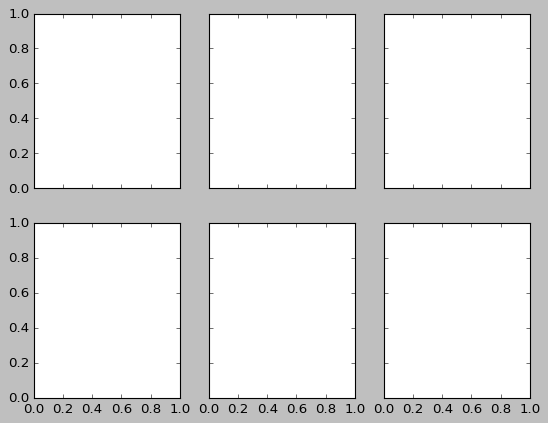

In [128]:
fig, ax = plt.subplots(2, 3, sharex='col', sharey='row')

Imajte na umu da smo specificiranjem `sharex` i `sharey` automatski uklonili unutrašnje oznake na mreži da bi parcela bila čistija. Dobijena mreža instanci osa se vraća unutar NumPy niza, omogućavajući pogodnu specifikaciju željenih osa pomoću notacija indeksiranja standardnog niza:

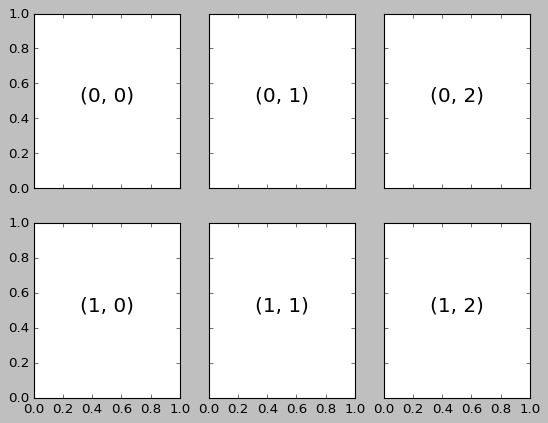

In [130]:
# axes are in a two-dimensional array, indexed by [row, col]
for i in range(2):
    for j in range(3):
        ax[i, j].text(0.5, 0.5, str((i, j)), fontsize=18, ha='center')
fig

U poređenju sa `plt.subplot()`, `plt.subplots()` je konzistentniji sa Pithonovim konvencionalnim indeksiranjem zasnovanim na 0.

## Kreiranje stubičastih dijagrama (bar plot) - funkcija `bar()`

Stubičaste dijagrame koristimo da reprezentujemo kategorijske podatke pravougaonicima čija je širina i visina proporcionalna  vrednostima koje reprezentujemo. Postoje horizonatalni i vertikalni stubičasti dijagrami. Uglavnom ih koristimo za poređenje  diskretnih kategorija podataka. Na jednoj osi se prikazuju kategorije, a na drugoj obično mera koja odgovara ovim kategorijama.

Sintaksa:
    ```python
    ax.bar(x, height, width, bottom, align)
    ```
:::{table} Parametri metoda (`ax.bar`) koji kreira stubičasti dijagram i njihov opis.
:label: ax.bar
:align: center
:header-rows: 1


|Parametar|Opis|
|:--------|:---|
|`x`      | Niz skalarnih vrednosti koje definišu x koordinate stubića (pravougaonika)|
|`height` | Skalar ili niz skalarnih vrednosti koje reprezentuju visinu stubića (pravougaonika)|
|`width`  | Opcioni parametar. Skalar ili niz skalarnih vrednosti koje reprezentuju širinu stubića (pravougaonika). Podrazumevana vrednost je 0.8|
|`bottom` | Opcioni parametar. Skalar ili niz skalarnih vrednosti. Podrazumevana vrednost je None|
|`align`  | Opcioni parametar. Vrednosti ovog parametra su: 'center', 'edge'.
:::

Funkcija `bar()` vraća matplotlib kontejner objekat sa svim stubićima. Detalje ove funkcije kao i primeri primene mogu se videti na veb adresi https://matplotlib.org/3.1.1/api/_as_gen/matplotlib.pyplot.bar.html

```{admonition} Primer 3.
:class: tip
Napisati kod koji sledi generiše stubičasti dijagram, koji reprezentuje broj knjiga po temama, na bazi rečnika:
~~~python
{'Pure Python':20, 'Numpy':25, 'Matplotlib':15,'Pandas':35}
~~~
```

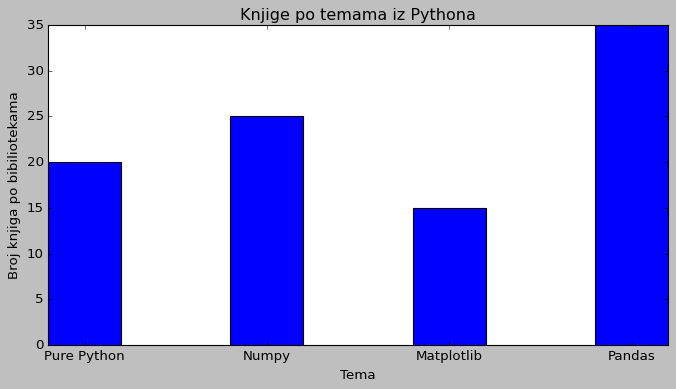

In [138]:
data = {'Pure Python':20, 'Numpy':25, 'Matplotlib':15,'Pandas':35}
teme = list(data.keys())
vrednosti = list(data.values())
fig = plt.figure(figsize = (10, 5))
plt.bar(teme, vrednosti, color ='blue', width = 0.4)
plt.xlabel("Tema")
plt.ylabel("Broj knjiga po bibiliotekama")
plt.title("Knjige po temama iz Pythona")
plt.show()

### Stekovani stubičasti dijagram (Dijagram naslagane trake)

Naslagane trake se koriste za predstavljanje različitih grupa podataka. Visina šipke uglavnom zavisi od rezultujuće visine kombinacije rezultata grupa. Visina ide od dna do vrednosti umesto da ide od nule do vrednosti.

Hajde sada da napravimo jedan naslagani dijagram. Kod je dat ispod.

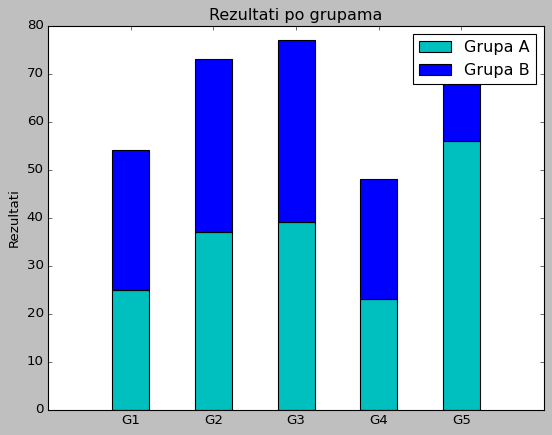

In [141]:
N = 5
group_a = (25, 37, 39, 23, 56)
group_b = (29, 36, 38, 25, 22)
ind = np.arange(N) # Lokacija grupe na x osi
width = 0.45
fig = plt.figure()
plt.bar(ind, group_a, width, color='c')
plt.bar(ind, group_b, width, bottom=group_a, color='b')
plt.ylabel('Rezultati')
plt.title('Rezultati po grupama')
plt.xticks(ind, ['G1', 'G2', 'G3', 'G4', 'G5'])
plt.yticks(np.arange(0, 81, 10))
plt.legend(labels=['Grupa A', 'Grupa B'])
plt.tick_params(bottom = False)
plt.show()

Evo još jednog primera:

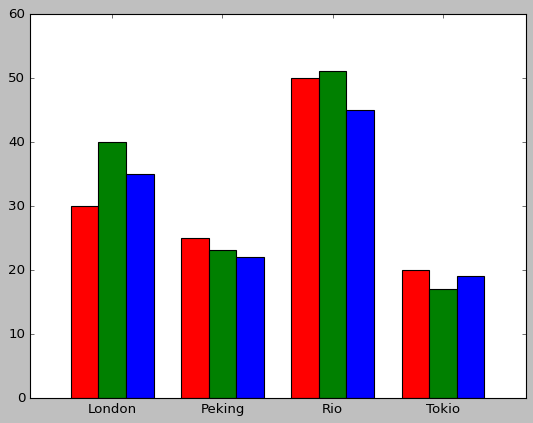

In [143]:
data = [[30, 25, 50, 20],[40, 23, 51, 17],[35, 22, 45, 19]]
X = np.arange(4)
fig = plt.figure()
plt.bar(X + 0.00, data[0], color = 'r', width = 0.25)
plt.bar(X + 0.25, data[1], color = 'g', width = 0.25)
plt.bar(X + 0.50, data[2], color = 'b', width = 0.25)
plt.xticks(X + 0.25, ['London', 'Peking', 'Rio', 'Tokio'])
plt.tick_params(bottom = False)
plt.show() 

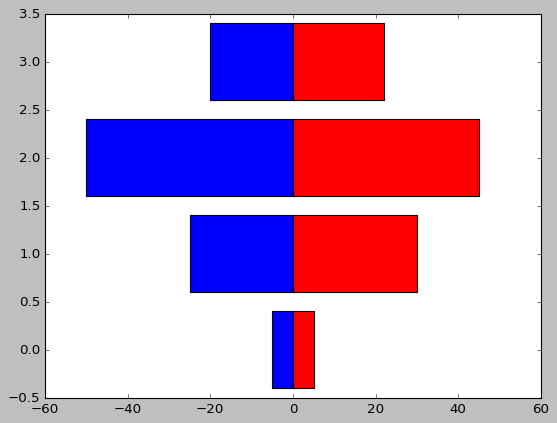

In [144]:
women_pop = np.array([5., 30., 45., 22.])
men_pop = np.array( [5., 25., 50., 20.])
X = np.arange(4)
plt.barh(X, women_pop, color = 'r')
plt.barh(X, -men_pop, color = 'b')
plt.show()

## Dijagram pita (pie chart)

Matplotlib podržava kružne grafikone pomoću funkcije `pie().` Detalji ove funkcije kao i primeri mogu se videti na linku https://matplotlib.org/3.1.1/api/_as_gen/matplotlib.pyplot.pie.html.

Kod u nastavku kreira kružni grafikon. Pored osnovnog kružnog grafikona, ovaj demo prikazuje nekoliko opcionih funkcija:
- nalepnice za kriške
- automatsko označavanje procenta
- nadoknaditi deo sa "eksplodirati"
- padajuća-senka
- prilagođeni početni ugao

Napomena o prilagođenom startnom uglu: 
Podrazumevani početni ugao je 0, što bi započelo presek "Žabe" na pozitivnoj k-osi. Ovaj primer postavlja početni ugao = 90 tako da se sve rotira u smeru suprotnom od kazaljke na satu za 90 stepeni, a kriška žabe počinje na pozitivnoj i-osi.

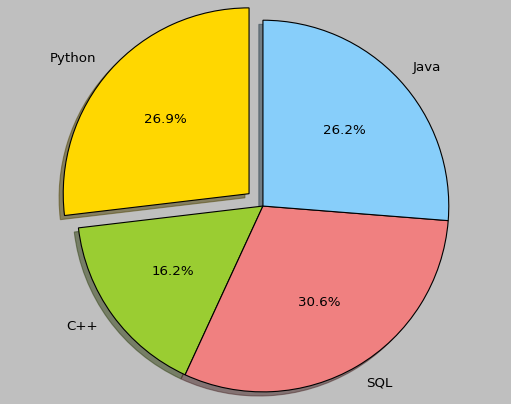

In [147]:
# Podaci za grafikon
labele = 'Python', 'C++', 'SQL', 'Java'
sizes = [215, 130, 245, 210]
colors = ['gold', 'yellowgreen', 'lightcoral', 'lightskyblue']
explode = (0.1, 0, 0, 0)  # istakni prvu krišku

# Plot
plt.pie(sizes, explode=explode, labels=labele, colors=colors, autopct='%1.1f%%', shadow=True, startangle=90)

plt.axis('equal')
plt.show()

Legende dodajemo jednostavno funkciom `plt.legend`:

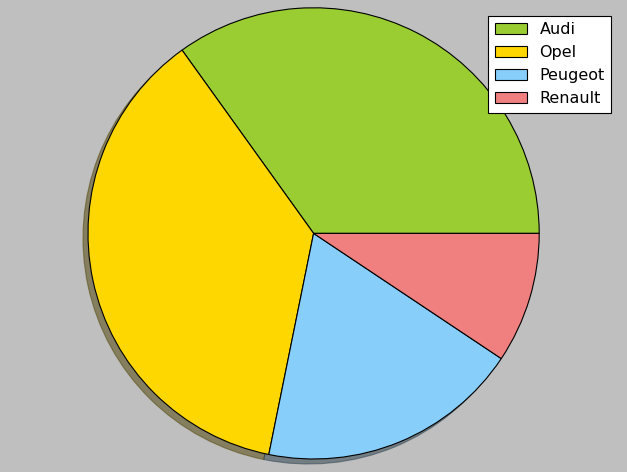

In [149]:
labels = ['Audi', 'Opel', 'Peugeot', 'Renault']
sizes = [38.4, 40.6, 20.7, 10.3]
colors = ['yellowgreen', 'gold', 'lightskyblue', 'lightcoral']
patches, texts = plt.pie(sizes, colors=colors, shadow=True, startangle=0)
plt.legend(patches, labels, loc="best")
plt.axis('equal')
plt.tight_layout()
plt.show()

Ako želimo da prikažemo samo deo pite svi podaci moraju biti u intervalu \[0,1\], njihov zbir ne može preći 1, a parametar `normalize` postavljen na `False`.

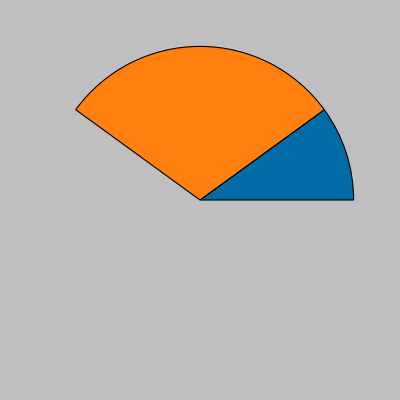

In [151]:
x=[0.1, 0.3]
plt.pie(x, normalize= False)
plt.show()

## Box plot (dijagram sa brkovima)

Boksplotovi su deskriptivni dijagrami koji pomažu pri poređenju distribucije različitih serija podataka. Oni su deskriptivni jer pokazuju mere (npr. medijana) koje ne pretpostavljaju osnovnu distribuciju verovatnoće. Za detale videti https://matplotlib.org/stable/api/_as_gen/matplotlib.pyplot.boxplot.html

Najosnovniji primer boksplot-a u matplotlib-u može se postići samo prosleđivanjem podataka kao višedimenzionalnih nizova:

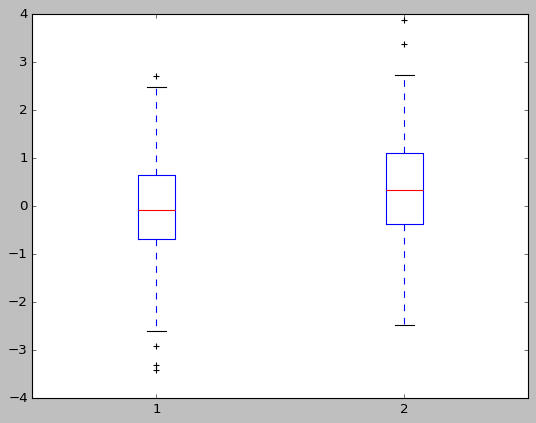

In [154]:
np.random.seed(2024)
X1 = np.random.normal(0, 1, 300)
X2 = np.random.normal(0.3, 1, 300)
data = (X1, X2)
plt.boxplot(data)
plt.show()

Matplotlib ima sopstvenu implementaciju boxplot-a. Okvirni dijagram prikazuje medijanu (percentil 50%) sa crvenom linijom. Kutija predstavlja Q1 i Q3 (percentili 25 i 75), a brkovi daju predstavu o opsegu podataka (Q1 - 1.5IQR i Q3 + 1.5IQR, gde je IQR interkvartilna razlika). Takođe primetite da su uzorci izvan ovog opsega prikazani kao markeri (oni se nazivaju outieri (letači)).

## Tekst i anotacija

Da bismo poboljšali razumevanje detalja grafikona, ponekad možemo dodati tekstualne napomene za objašnjenja. Možemo da dodamo tekst u našu grafiku tako što ćemo pozvati `plt.text(x,y,text)` gde su `x` i `y` koordinate pozicije na koju treba postaviti
tekstualni niz `text`. Evo kratkog primera:

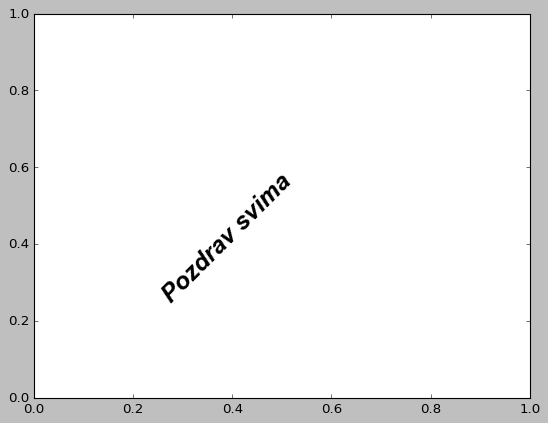

In [158]:
plt.text(0.25, 0.25, "Pozdrav svima", fontsize=22, fontweight = 'bold', fontstyle='italic', fontfamily='arial', rotation=45)
plt.show()

#### Anotacija

Upotreba osnovnog `text()` će postaviti tekst na proizvoljnu poziciju na objektu Axes. Uobičajeni slučaj upotrebe teksta je da se označi neka karakteristika dijagrama, a metoda `annotate()` pruža pomoćnu funkcionalnost da bi se napomene učinile lakim. Za detalje videti https://matplotlib.org/stable/tutorials/text/annotations.html

Sintaksa:
```python
matplotlib.pyplot.annotate(text, xy, *args, **kwargs)
```

Parameteri
- `text`: string, tekst za anotaciju.
- `xy`: (float, float), tačka (x, y) koja se anotira. Koordinatni sistem se određuje pomoću `xycoords`.
- `xytext`: (float, float), pozicija na koju se smešta tekst
- `xycoords`: definiše koordinatni sistem. Podrazumevano `data`, odnosno u skladu sa podacima.

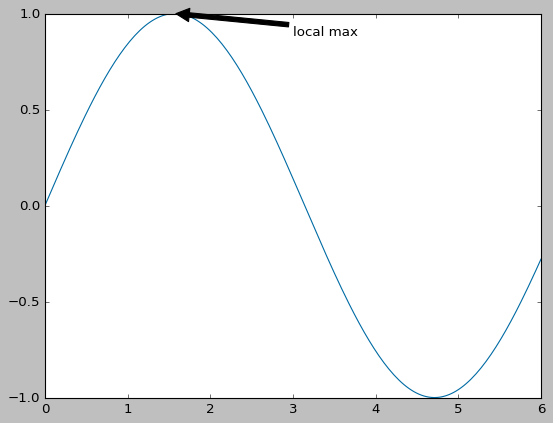

In [161]:
fig, ax = plt.subplots()
x=np.linspace(0, 6, 200)
y = np.sin(x)
ax.plot(x,y)
ax.annotate('local max', xy=(1.57, 1),  xycoords='data',
            xytext=(0.63, 0.97), textcoords='axes fraction',
            arrowprops=dict(facecolor='black', shrink= 0.01),
            horizontalalignment='right', verticalalignment='top',
            )
plt.show()

## Popunjavanje oblasti između dve horizontalne krive.

Neka su krive su definisane nizovima `(x, y1)` i `(x, y2)`. One stvaraju jednu ili više oblasti. Neke delove možemo isključiti naredbom `where`. Podrazumevano, ivice direktno povezuju date tačke. Koristite `step` (korak) ako punjenje treba da bude funkcija koraka, tj. konstanta između `x`. Sintaksa:

```python
matplotlib.pyplot.fill_between(x, y1, y2=0, where=None, interpolate=False, step=None, *, data=None, **kwargs)
```
:::{table} Parametri metoda `fill_between` koji boji oblast između dve krive.
:label: fill_between
:align: center
:header-rows: 1

|Parametar | Tip, vrsta i značenje|
|:---------|:--------|
|`x`       | niz (dužine N). Koordinate x tačaka koji definišu krive.|
|`y1`      | niz (dužine N) ili skalar. Koordinate tačaka definišu prvu krivu.|
|`y2`      | niz (dužine N) ili skalar. Koordinate tačaka definišu drugu krivu.|
|where     | bulov niz (dužine N), opcioni. Definišite gde da isključite neke horizontalne regione iz popunjavanja. Popunjeni regioni su definisani koordinatama `x[where]`. Tačnije, popunite između `x[i]` i `x[i+1]` ako je `where[i]` i `where[i+1]`. Imajte na umu da ova definicija implicira da izolovana vrednost `True` između dve vrednosti `False` neće rezultirati popunjavanjem. Obe strane pozicije `True` ostaju nepopunjene zbog susednih vrednosti `False`.|
|`interpolate`| Bool, podrazumevano: False. Ova opcija je relevantna samo ako se koristi `where` i dve krive se ukrštaju. Semantički, gde se često koristi za `y1 > y2` ili slično. Podrazumevano, Tačke oblasti koji definišu popunjeni region biće postavljeni samo na pozicije u `x` nizu. Takva oblast ne može opisati gornjom semantikom blizu raskrsnice. Xs-preseci koji sadrže presek se jednostavno iseču. Postavljanje interpolacije na Tačno će izračunati stvarnu tačku preseka i proširiti popunjenu oblast do ove tačke.|
|`step`| vrednosti: {'before', 'post', 'mid'}, opciono. Definiše korak ako popunjavanje treba da bude funkcija koraka, tj. konstanta između `x`-ova. Vrednost određuje gde će se korak dogoditi: 'before': vrednost i se nastavlja stalno ulevo od svake `x` pozicije, tj. interval `(x[i-1], x[i]]` ima vrednost `x[i]`. 'post': `x` vrednost se nastavlja stalno udesno sa svake `x` pozicije, tj. interval `([x[i], x[i+1])` ima vrednost `x[i]`. 'mid: Koraci se javljaju na pola puta između `x` pozicija.|

:::

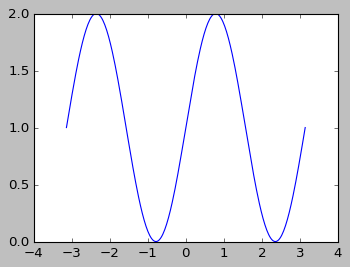

In [164]:
fig=plt.figure(figsize=(4,3))
n = 256
X = np.linspace(-np.pi, np.pi, n)
Y = np.sin(2 * X)
plt.axes([0.025, 0.025, 0.95, 0.95]) 
# markira deo figure u kojem smešta grafik, tj. pravougaonik dole, levo, gore, desno unutar jediničnog kvadrata
plt.plot(X, Y + 1, color='blue', alpha=1.00)
plt.show()


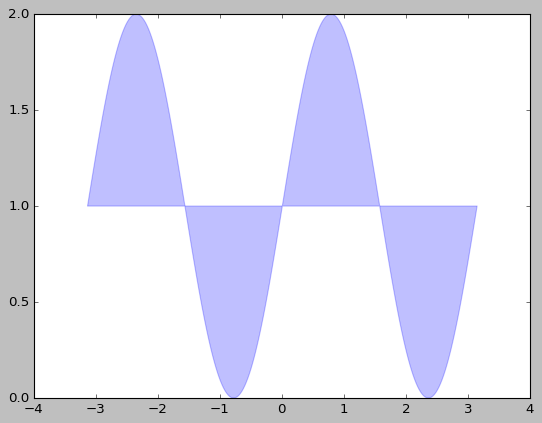

In [165]:
plt.fill_between(X, 1, Y + 1, color='blue', alpha=.25)
plt.show()

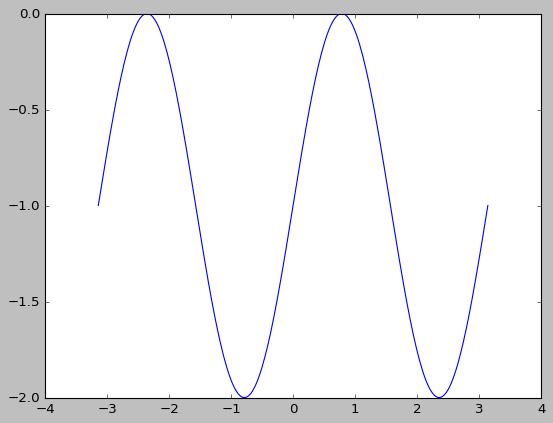

In [166]:
plt.plot(X, Y - 1, color='blue', alpha=1.00)
plt.show()

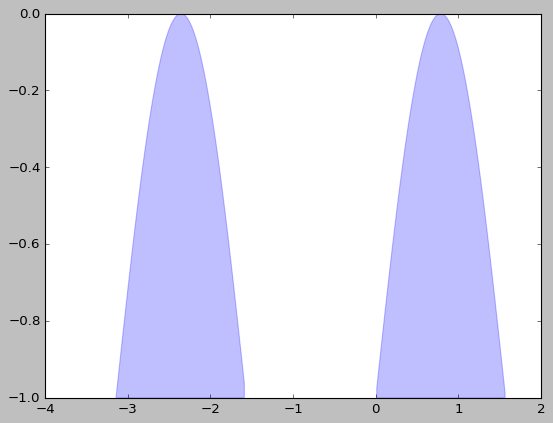

In [167]:
plt.fill_between(X, -1, Y - 1, (Y - 1) > -1, color='blue', alpha=.25)
plt.show()

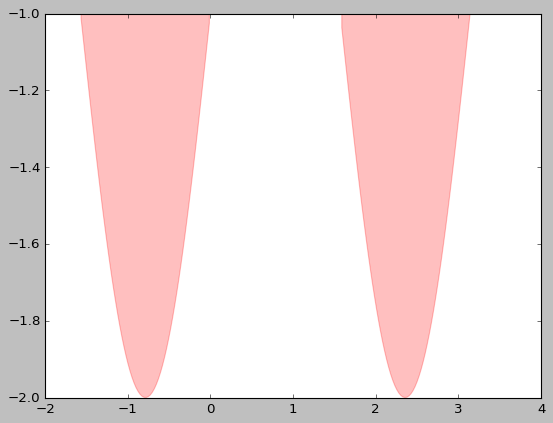

In [168]:
plt.fill_between(X, -1, Y - 1, (Y - 1) < -1, color='red', alpha=.25)
plt.show()

<br>

## Vežbanja

#### ✍️ Vežba 1.

## Zadaci i problemi

#### ⚡️ Zadatak 1.

Kirkland Industrija prodaje vazdušne kompresore proizvodnim preduzećima. U tabeli se nalazi količina prodaje kompresora u stotinama dolara, za svaki mesec. Prikažite dijagram rasturanja i stubičasti dijagram za date podatke.
:::{table} Kirkland industrija
:class: thin
:label: plot_z1
:align: center
|             |      |     |      |     |     |     |     |     |      |     |     |     |
| :--         | :-:  | :-: | :-:  | :-: | :-: | :-: | :-: | :-: | :-:  | :-: | :-: | :-: |
| **Mesec**   | Jan  | Feb | Mar  | Apr | Maj | Jun | Jul | Avg | Sep  | Okt | Nov | Dec |
| **Prodaja** | 135  | 145 | 175  | 180 | 160 | 135 | 210 | 175 | 160  | 120 | 115 | 120 |
:::

#### ⚡️Zadatak 2.

Meteorološka stanica je tokom meseca maja beležila prosečne dnevne temperature (°C) u Beogradu. Cilj je da se analiziraju podaci i prikažu osnovni pokazatelji i grafički trend promena temperature tokom meseca.

Podaci: Temperatura po danima (1–30):
```python
temperature = np.array([ 16.2, 17.5, 19.8, 21.1, 22.4, 20.9, 18.3, 19.0, 21.7, 23.5, 25.1, 27.3, 28.0, 29.2, 30.4, 31.0, 29.8, 28.7, 27.1, 25.5,
    24.8, 23.0, 21.6, 19.5, 18.0, 17.2, 16.8, 18.9, 20.5, 22.1 ])
```
1. Izračunati i ispisati sledeće vrednosti: prosečnu mesečnu temperaturu, najvišu i najnižu dnevnu temperaturu, standardnu devijaciju temperatura.

2. Prikazati linijski grafikon koji pokazuje promenu temperature po danima:
   * x-osa: dani (1–30)
   * y-osa: temperatura (°C)
   * obeležiti najvišu i najnižu temperaturu drugačijim bojama i markerima
   * dodati horizontalnu liniju prosečne temperature (npr. isprekidanu liniju).
   * Na grafikonu jasno označiti naslov, nazive osa i mrežu (`grid`).

3. Pronađi sve dane kada je temperatura bila iznad prosečne vrednosti i: označi te tačke crvenom bojom na grafikonu,
prebroj koliko je bilo takvih dana, ispiši njihov procenat u odnosu na ukupan broj dana u mesecu.


<br>

## Studije slučaja

In [ ]:
🧩 